# Lecture 10 (file family L09) · Boxes, IoU, matching and AP from scratch

**One exact geometry-and-evaluation pipeline, grounded in two real images.** You will audit two official Oxford-IIIT Pet head boxes, map a constructed five-candidate ledger onto those photographs, implement IoU, inspect a training loss, match scored detections within each image, build precision–recall points, and verify anchor encode/decode.

Work in this rhythm: **predict → calculate → run → inspect → explain**. The photographs and XML ROIs are observed/ground truth; A–E, their scores, and affine placement are constructed; IoU, NMS, matching, overlays, and AP are computed. **No detector was run.**

**Clock map:** `TRAIN` compares predictions with assigned targets; `INFER` decodes boxes and scores; `EVAL` matches a frozen ranked list to ground truth. This notebook crosses `TRAIN → EVAL`; the companion NMS notebook owns the `INFER` clock.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

np.set_printoptions(precision=3, suppress=True)
TEAL, ORANGE, GREEN, RED = '#2A7F7F', '#F57C00', '#20A84A', '#E34850'

## 0 · Audit the real two-image evidence contract

`I1=Abyssinian_1` and `I2=Bengal_10` are real Oxford-IIIT Pet photographs. Each has its own official XML tight-head ROI. A/B/E belong to I1; C/D belong to I2. Their boxes and scores are a **constructed teaching ledger, not model output**. Positive affine maps preserve the canonical IoUs exactly.

The loader is local-first. In Colab it downloads only SHA-pinned repository assets and rejects any byte mismatch.

I1: Abyssinian_1  GT=[332, 71, 425, 158]  pixels=[600, 400]
I2: Bengal_10  GT=[314, 59, 446, 219]  pixels=[500, 375]
OBSERVED/GT verified; CONSTRUCTED A–E; COMPUTED geometry; MODEL OUTPUT none


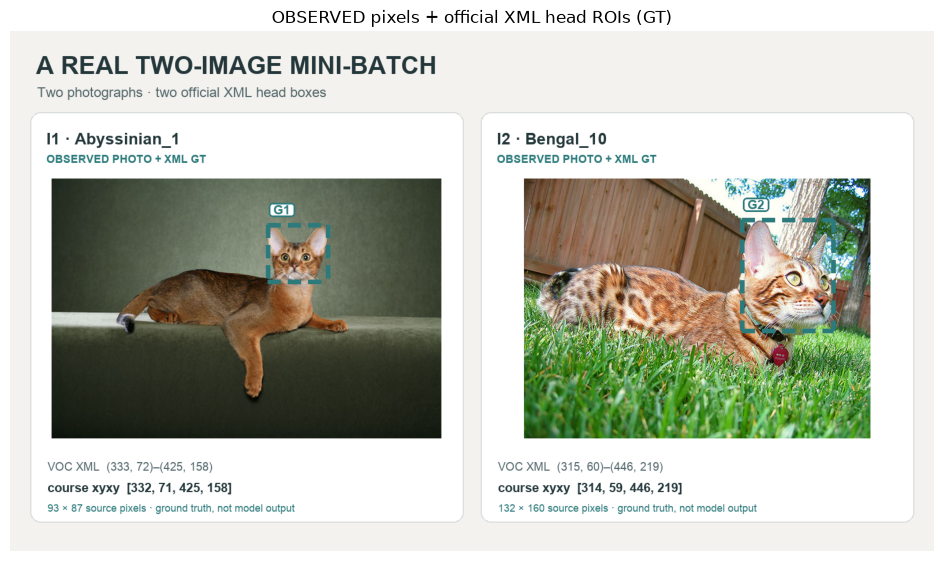

In [2]:
from pathlib import Path
from urllib.request import urlretrieve
import csv, hashlib, json, tempfile
import xml.etree.ElementTree as ET

RAW_ROOT = 'https://raw.githubusercontent.com/nipunbatra/dl-teaching/master/'
ASSET_SPECS = {
    'manifest': ('shared/vision-evidence/oxford-iiit-pet/l9/evidence.json', 'b539bc41f383d52f95ed2abeeaf764ccf325a1a03b000be7d377b075cac2836a'),
    'candidates': ('shared/vision-evidence/oxford-iiit-pet/l9/candidates.csv', '3a270c23854ed92d0870c796df7db2b1b33a73a69a1c39dee47be9bbd5d1d4fa'),
    'evaluation': ('shared/vision-evidence/oxford-iiit-pet/l9/evaluation.csv', 'b1cccbd5b1b0860a540e48715e4781f1922f0184059bb0d4527a0d1b189018e1'),
    'targets_plate': ('shared/vision-evidence/oxford-iiit-pet/l9/real-head-targets.png', '4492e5bcda0b32f8a30923eead220f2d6381c7bc5b49fb7d48eb4f5cc1400217'),
    'candidates_plate': ('shared/vision-evidence/oxford-iiit-pet/l9/real-candidates.png', '1ca4372b8c062c4e4cb183c060669bdf3ea99c7884f0ae13f822f65f4570cdb6'),
    'eval_plate': ('shared/vision-evidence/oxford-iiit-pet/l9/real-eval-matching.png', 'db6f20189f53afbc5a7a14c1075134e2729c05ad4053b40c552599579e58f25c'),
    'i1_image': ('shared/vision-evidence/oxford-iiit-pet/Abyssinian_1.jpg', '2533197401eebe9410ea4d063f86c43fbd2666f3e8165a38aca155c0d09c21be'),
    'i1_xml': ('shared/vision-evidence/oxford-iiit-pet/Abyssinian_1.xml', 'bea13ddcf1dc171e39da5ce2c134b1dc8c247a9f1bb21cc2056f37f7a423a51f'),
    'i2_image': ('shared/vision-evidence/oxford-iiit-pet/l9/Bengal_10.jpg', '4cc958fc6bb47738488fdc83a3053f01ce2937c9fbcaf5db2e649a1d612f8725'),
    'i2_xml': ('shared/vision-evidence/oxford-iiit-pet/l9/Bengal_10.xml', '9a6e7d513d999b23cde839a6efce908e2e1472d14d69f13d671e9db9cdb09ae6'),
}

def sha256(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()

def local_first(key):
    rel, expected = ASSET_SPECS[key]
    for root in (Path.cwd(), *Path.cwd().parents):
        candidate = root / rel
        if candidate.is_file() and sha256(candidate) == expected:
            return candidate
    cache = Path(tempfile.gettempdir()) / 'dl-teaching-l09-evidence'
    cache.mkdir(parents=True, exist_ok=True)
    target = cache / Path(rel).name
    if not target.is_file() or sha256(target) != expected:
        urlretrieve(RAW_ROOT + rel, target)
    actual = sha256(target)
    assert actual == expected, f'{key}: SHA mismatch {actual}'
    return target

manifest = json.loads(local_first('manifest').read_text())
assert manifest['schema_version'] == 2
assert manifest['build']['builder_sha256'] == '1e6d3312df89424974b1fab8ccdbc5e11963dd4b6d6c802d64d33b09380fb3e1'
assert manifest['evidence_taxonomy']['model_output'] == []

def voc_half_open(path):
    box = ET.parse(path).getroot().find('.//bndbox')
    xmin, ymin, xmax, ymax = [int(box.find(k).text) for k in ('xmin','ymin','xmax','ymax')]
    return [xmin - 1, ymin - 1, xmax, ymax]

for image_id, xml_key in [('I1','i1_xml'), ('I2','i2_xml')]:
    sample = manifest['source']['samples'][image_id]
    assert voc_half_open(local_first(xml_key)) == sample['gt_source_xyxy_half_open']
    image = plt.imread(local_first(image_id.lower() + '_image'))
    assert [image.shape[1], image.shape[0]] == sample['image_size']
    print(f"{image_id}: {sample['stem']}  GT={sample['gt_source_xyxy_half_open']}  pixels={sample['image_size']}")
print('OBSERVED/GT verified; CONSTRUCTED A–E; COMPUTED geometry; MODEL OUTPUT none')

fig, ax = plt.subplots(figsize=(12, 6.75))
ax.imshow(plt.imread(local_first('targets_plate')))
ax.axis('off'); ax.set_title('OBSERVED pixels + official XML head ROIs (GT)')
plt.show()

## 1 · Convert and normalize a box

A cat occupies corner-form box $[160,96,480,336]$ in a $640\times480$ image.

**Predict before running:** what are $(x_c,y_c,w,h)$ in pixels? Which three normalized coordinates equal $0.5$?

In [3]:
W, H = 640, 480
corner = np.array([160., 96., 480., 336.])
xmin, ymin, xmax, ymax = corner
center_size = np.array([(xmin+xmax)/2, (ymin+ymax)/2, xmax-xmin, ymax-ymin])
normalized = center_size / np.array([W, H, W, H])
print('center-size pixels :', center_size)
print('normalized target  :', normalized)
assert np.allclose(center_size, [320, 216, 320, 240])
assert np.allclose(normalized, [0.50, 0.45, 0.50, 0.50])

center-size pixels : [320. 216. 320. 240.]
normalized target  : [0.5  0.45 0.5  0.5 ]


## 2 · Implement IoU safely

Boxes use corner form $[x_{min},y_{min},x_{max},y_{max}]$ with **continuous/half-open edges**: width is $x_{max}-x_{min}$, with no inclusive-pixel `+1`. The intersection width and height must be clamped at zero.

**Calculate first:** for $A=[0,0,10,10]$ and $B=[5,5,15,15]$, find intersection area, union area and IoU.

In [4]:
def box_area(box):
    x0, y0, x1, y1 = box
    return max(0.0, x1-x0) * max(0.0, y1-y0)

def iou(a, b, return_parts=False):
    left, top = max(a[0], b[0]), max(a[1], b[1])
    right, bottom = min(a[2], b[2]), min(a[3], b[3])
    iw, ih = max(0.0, right-left), max(0.0, bottom-top)
    inter = iw * ih
    union = box_area(a) + box_area(b) - inter
    value = inter / union if union > 0 else 0.0
    return (value, inter, union) if return_parts else value

A = np.array([0., 0., 10., 10.])
B = np.array([5., 5., 15., 15.])
value, inter, union = iou(A, B, return_parts=True)
print(f'intersection={inter:.0f}, union={union:.0f}, IoU={value:.3f}')
assert np.isclose(value, 25/175)
assert iou(A, np.array([20., 20., 30., 30.])) == 0.0

intersection=25, union=175, IoU=0.143


### Real-image bridge · the same IoUs survive each affine map

The canonical ledger remains the arithmetic source of truth. We map A/B/E onto I1 and C/D onto I2 with separate positive x/y affine maps. This changes pixel coordinates but preserves every within-image IoU.

**Predict:** should a box from I1 ever be compared with a box from I2 during NMS or matching?

A  I1  canonical=[10.0, 10.0, 50.0, 50.0]  source=[332.0, 71.0, 425.0, 158.0]
B  I1  canonical=[12.0, 12.0, 52.0, 52.0]  source=[336.65, 75.35, 429.65, 162.35]
E  I1  canonical=[35.0, 5.0, 55.0, 25.0]  source=[390.125, 60.125, 436.625, 103.625]
C  I2  canonical=[60.0, 15.0, 90.0, 55.0]  source=[314.0, 59.0, 446.0, 219.0]
D  I2  canonical=[63.0, 17.0, 91.0, 56.0]  source=[327.2, 67.0, 450.4, 223.0]
IoU(A,B) = 0.822323 in canonical and source pixels
IoU(C,D) = 0.810427 in canonical and source pixels
IoU(A,E) = 0.126761 in canonical and source pixels


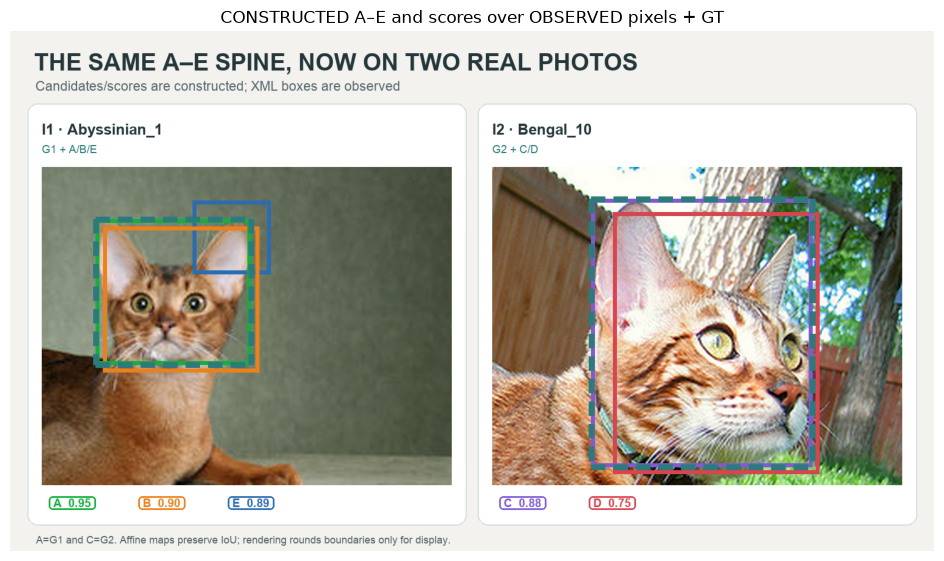

In [5]:
with local_first('candidates').open(newline='') as handle:
    candidate_rows = list(csv.DictReader(handle))

candidate_by_id = {row['id']: row for row in candidate_rows}
for candidate_id in ['A','B','E','C','D']:
    row = candidate_by_id[candidate_id]
    canonical = np.array([float(row[f'canonical_{axis}']) for axis in ('x0','y0','x1','y1')])
    source = np.array([float(row[f'source_{axis}']) for axis in ('x0','y0','x1','y1')])
    recorded = np.array(manifest['candidates'][candidate_id]['source_box'])
    assert np.allclose(source, recorded)
    assert row['evidence_type'] == 'constructed; not model output'
    print(f"{candidate_id}  {row['image']}  canonical={canonical.tolist()}  source={source.tolist()}")

def row_box(candidate_id, prefix):
    row = candidate_by_id[candidate_id]
    return np.array([float(row[f'{prefix}_{axis}']) for axis in ('x0','y0','x1','y1')])

checks = [('A','B',361/439), ('C','D',171/211), ('A','E',9/71)]
for left, right, expected in checks:
    canonical_iou = iou(row_box(left,'canonical'), row_box(right,'canonical'))
    source_iou = iou(row_box(left,'source'), row_box(right,'source'))
    assert np.isclose(canonical_iou, expected) and np.isclose(source_iou, expected)
    print(f'IoU({left},{right}) = {expected:.6f} in canonical and source pixels')
assert candidate_by_id['A']['image'] == candidate_by_id['B']['image'] == candidate_by_id['E']['image'] == 'I1'
assert candidate_by_id['C']['image'] == candidate_by_id['D']['image'] == 'I2'

fig, ax = plt.subplots(figsize=(12, 6.75))
ax.imshow(plt.imread(local_first('candidates_plate')))
ax.axis('off'); ax.set_title('CONSTRUCTED A–E and scores over OBSERVED pixels + GT')
plt.show()

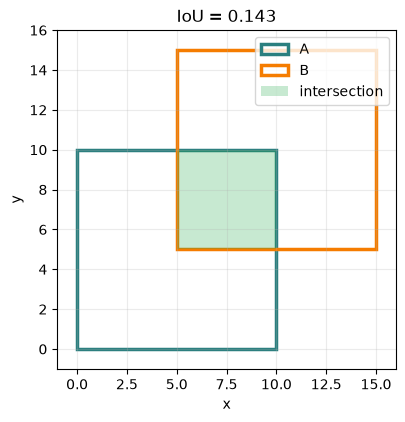

In [6]:
fig, ax = plt.subplots(figsize=(5.2, 4.4))
for box, color, label in [(A, TEAL, 'A'), (B, ORANGE, 'B')]:
    x0, y0, x1, y1 = box
    ax.add_patch(Rectangle((x0,y0), x1-x0, y1-y0, fill=False, lw=2.5, ec=color, label=label))
ax.add_patch(Rectangle((5,5), 5, 5, fc=GREEN, alpha=.25, ec='none', label='intersection'))
ax.set(xlim=(-1,16), ylim=(-1,16), xlabel='x', ylabel='y', title=f'IoU = {value:.3f}')
ax.set_aspect('equal'); ax.grid(alpha=.25); ax.legend(); plt.show()

## 3 · `TRAIN` — coordinate loss and overlap answer different questions

The normalized target is $b=(0.50,0.45,0.50,0.50)$ and the prediction is $\hat b=(0.55,0.40,0.60,0.45)$.

**Predict:** the $L_1$ sum is $0.25$. Will smooth-$L_1$ be larger or smaller when every residual has magnitude below 1?

In [7]:
b_true = np.array([0.50, 0.45, 0.50, 0.50])
b_pred = np.array([0.55, 0.40, 0.60, 0.45])
residual = b_pred - b_true

def smooth_l1(r):
    a = np.abs(r)
    return np.where(a < 1, 0.5*r*r, a-0.5)

print('residuals        :', residual)
print('L1 sum           :', np.abs(residual).sum())
print('smooth-L1 sum    :', smooth_l1(residual).sum())

def center_to_corner(box):
    xc, yc, w, h = box
    return np.array([xc-w/2, yc-h/2, xc+w/2, yc+h/2])

pair_iou = iou(center_to_corner(b_true), center_to_corner(b_pred))
print('IoU, same pair   :', pair_iou)
print('classification CE:', -np.log(0.80))
print('total, lambda=2  :', -np.log(0.80) + 2*np.abs(residual).sum())
assert np.isclose(pair_iou, 0.2125/0.3075)

residuals        : [ 0.05 -0.05  0.1  -0.05]
L1 sum           : 0.25
smooth-L1 sum    : 0.008749999999999997
IoU, same pair   : 0.6910569105691055
classification CE: 0.2231435513142097
total, lambda=2  : 0.7231435513142097


## 4 · `EVAL` — match predictions one-to-one

Our held mini-batch contains two real images and two official head truths: $G_1$ belongs to I1 and $G_2$ belongs to I2. `INFER` began with constructed A, B, E, C, D, then per-image/class NMS returned A, E, C. On the `EVAL` clock, each returned detection claims the best **unmatched truth in the same image and class** at $IoU \ge \tau$. The detections are then ranked globally by score.

**Predict:** which of returned detections A, E, C are true positives? Why can neither NMS nor matching compare boxes across I1 and I2?

In [8]:
gt = np.array([[10,10,50,50], [60,15,90,55]], float)
gt_images = np.array(['I1','I2'])
gt_classes = np.array(['head','head'])
raw_pred = np.array([
    [10,10,50,50],   # A: exact G1
    [12,12,52,52],   # B: duplicate G1
    [35, 5,55,25],   # E: false alarm
    [60,15,90,55],   # C: exact G2
    [63,17,91,56],   # D: duplicate G2
], float)
raw_names = np.array(['A','B','E','C','D'])
raw_images = np.array(['I1','I1','I1','I2','I2'])
raw_classes = np.array(['head','head','head','head','head'])
raw_scores = np.array([.95,.90,.89,.88,.75])
returned_idx = np.array([0,2,3])  # NMS at tau=.50 keeps A, E, C
pred, names, scores = raw_pred[returned_idx], raw_names[returned_idx], raw_scores[returned_idx]
pred_images, pred_classes = raw_images[returned_idx], raw_classes[returned_idx]
iou_matrix = np.array([
    [iou(p,g) if (pred_images[i] == gt_images[j] and pred_classes[i] == gt_classes[j]) else np.nan
     for j,g in enumerate(gt)]
    for i,p in enumerate(pred)
])
print('raw mini-batch :', list(zip(raw_names, raw_images)))
print('NMS returned   :', names.tolist())
print('EVAL rows A,E,C; columns G1,G2; nan = forbidden cross-image comparison')
print(iou_matrix)

raw mini-batch : [('A', 'I1'), ('B', 'I1'), ('E', 'I1'), ('C', 'I2'), ('D', 'I2')]
NMS returned   : ['A', 'E', 'C']
EVAL rows A,E,C; columns G1,G2; nan = forbidden cross-image comparison
[[1.      nan]
 [0.127   nan]
 [  nan 1.   ]]


In [9]:
def greedy_match(iou_matrix, threshold=0.5):
    used_truths = set()
    is_tp, claimed = [], []
    for row in iou_matrix:              # predictions already score-sorted
        available = [j for j in range(len(row)) if j not in used_truths and np.isfinite(row[j])]
        if not available:
            is_tp.append(False)
            claimed.append(None)
            continue
        j = max(available, key=lambda candidate: row[candidate])
        ok = row[j] >= threshold
        is_tp.append(ok)
        claimed.append(j if ok else None)
        if ok: used_truths.add(j)
    return np.array(is_tp), claimed

is_tp, claimed = greedy_match(iou_matrix, threshold=.5)
for name, image_id, score, row, tp, claim in zip(names, pred_images, scores, iou_matrix, is_tp, claimed):
    result = f'TP, claims G{claim+1}' if tp else 'FP'
    print(f'{name} ({image_id}): score={score:.2f}, best eligible IoU={np.nanmax(row):.3f} -> {result}')
assert is_tp.tolist() == [True, False, True]
assert claimed == [0, None, 1]

# Regression test: the second prediction must be allowed to claim its second-best, unmatched truth.
edge_tp, edge_claimed = greedy_match(np.array([[.90, .00], [.90, .80]]), threshold=.5)
assert edge_tp.tolist() == [True, True] and edge_claimed == [0, 1]

A (I1): score=0.95, best eligible IoU=1.000 -> TP, claims G1
E (I1): score=0.89, best eligible IoU=0.127 -> FP
C (I2): score=0.88, best eligible IoU=1.000 -> TP, claims G2


COMPUTED batch evaluation: A(I1)=TP, E(I1)=FP, C(I2)=TP; AP=5/6


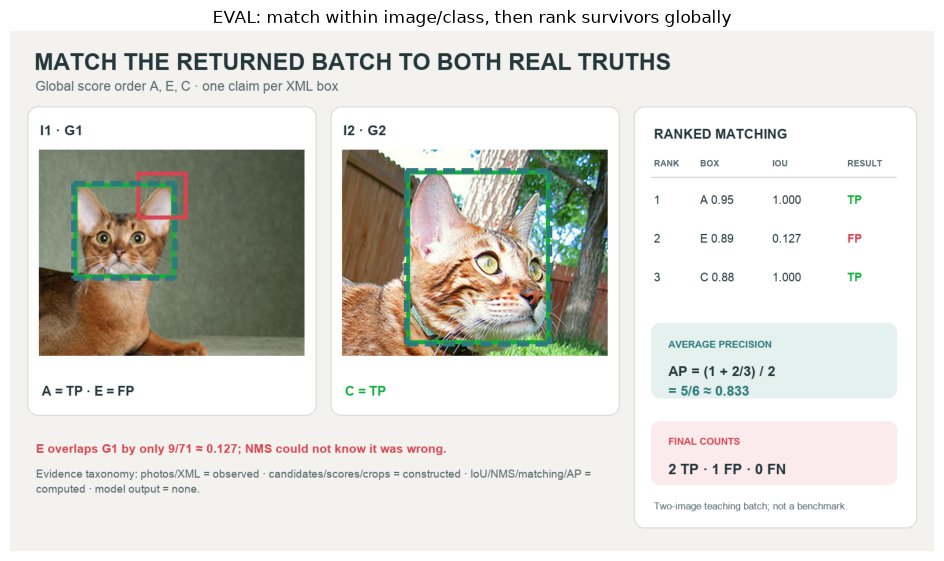

In [10]:
with local_first('evaluation').open(newline='') as handle:
    evaluation_rows = list(csv.DictReader(handle))

assert [(row['candidate'], row['image'], row['result']) for row in evaluation_rows] == [
    ('A','I1','TP'), ('E','I1','FP'), ('C','I2','TP')
]
assert [row['precision'] for row in evaluation_rows] == ['1','1/2','2/3']
assert [row['recall'] for row in evaluation_rows] == ['1/2','1/2','1']
assert all(row['ap'] == '5/6' for row in evaluation_rows)
print('COMPUTED batch evaluation: A(I1)=TP, E(I1)=FP, C(I2)=TP; AP=5/6')

fig, ax = plt.subplots(figsize=(12, 6.75))
ax.imshow(plt.imread(local_first('eval_plate')))
ax.axis('off'); ax.set_title('EVAL: match within image/class, then rank survivors globally')
plt.show()

## 5 · `EVAL` — build precision–recall points from the ranking

After each prediction enters, recompute cumulative TP, precision and recall.

**Calculate first:** E enters between A and C. What happens to precision before C raises recall from $1/2$ to $1$?

We report **rank AP@0.50 for one class**: average precision at ranks where recall increases. This is not COCO mAP; COCO interpolates precision at 101 recall points, then averages over classes and IoU thresholds $0.50{:}0.95$.

In [11]:
tp_cum = np.cumsum(is_tp)
fp_cum = np.cumsum(~is_tp)
precision = tp_cum / (tp_cum + fp_cum)
recall = tp_cum / len(gt)
for n, p, r in zip(names, precision, recall):
    print(f'after {n}: precision={p:.3f}, recall={r:.3f}')

# One-class rank AP@0.50: average precision at ranks where a new TP appears.
ap = precision[is_tp].sum() / len(gt)
print(f'rank AP@0.50 = ({precision[is_tp][0]:.3f} + {precision[is_tp][1]:.3f}) / 2 = {ap:.3f}')
assert np.isclose(ap, 5/6)

after A: precision=1.000, recall=0.500
after E: precision=0.500, recall=0.500
after C: precision=0.667, recall=1.000
rank AP@0.50 = (1.000 + 0.667) / 2 = 0.833


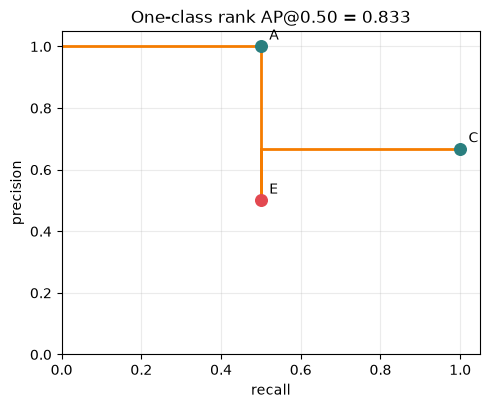

In [12]:
fig, ax = plt.subplots(figsize=(5.4,4.2))
# `pre` makes each recall interval use the precision at the rank that reaches it.
ax.step(np.r_[0, recall], np.r_[1, precision], where='pre', color=ORANGE, lw=2)
for n, r, p in zip(names, recall, precision):
    ax.scatter(r,p,color=TEAL if n in ['A','C'] else RED, s=70, zorder=3)
    ax.annotate(n,(r,p),xytext=(6,5),textcoords='offset points')
ax.set(xlim=(0,1.05), ylim=(0,1.05), xlabel='recall', ylabel='precision', title=f'One-class rank AP@0.50 = {ap:.3f}')
ax.grid(alpha=.25); plt.show()

## 6 · `TRAIN ↔ INFER` — encode and decode one anchor

Anchor $a=(50,50,40,40)$ and matched box $b=(58,46,80,40)$ use center-size form.

**Predict:** which offset is zero? Which offset is $\log 2$?

In [13]:
def encode(anchor, box):
    xa, ya, wa, ha = anchor
    x, y, w, h = box
    return np.array([(x-xa)/wa, (y-ya)/ha, np.log(w/wa), np.log(h/ha)])

def decode(anchor, t):
    xa, ya, wa, ha = anchor
    tx, ty, tw, th = t
    return np.array([xa+tx*wa, ya+ty*ha, wa*np.exp(tw), ha*np.exp(th)])

anchor = np.array([50.,50.,40.,40.])
target = np.array([58.,46.,80.,40.])
offset = encode(anchor, target)
recovered = decode(anchor, offset)
print('encoded offsets:', offset)
print('decoded box    :', recovered)
assert np.allclose(recovered, target)

encoded offsets: [ 0.2   -0.1    0.693  0.   ]
decoded box    : [58. 46. 80. 40.]


## Explain, do not merely report

In two or three sentences each:

1. Why must NMS and matching group records by image identity before comparing IoU?
2. Why are constructed duplicate candidates B and D absent from the `EVAL` ranked list?
3. Why is E a false positive even though it survived NMS?
4. What does the score control during AP evaluation, and what does the IoU threshold control?
5. Why regress offsets from an anchor rather than unconstrained raw pixel coordinates?

## Takeaway

- The photos and XML ROIs are observed/GT; A–E and their scores are constructed; all geometry and overlays are computed; there is no model output.
- A box is four numbers, but IoU measures the geometry those numbers create. Positive affine maps preserve IoU.
- Detection evaluation is **image-aware, ranked, class-aware and one-to-one**; boxes from different images are never eligible matches.
- `TRAIN` uses assigned targets and losses; `INFER` decodes; `EVAL` performs one-to-one matching on a frozen ranked list.
- Rank AP@0.50 summarizes this one-class ranking; COCO mAP uses a broader interpolation-and-averaging protocol.
- Anchor offsets are a well-scaled parameterization for learning box corrections.